In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="white")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
# NAV History

nav = pd.read_csv(r"C:\Users\tekam\Downloads\Data Science\Data_Analyst_Portfolio_Project\data\raw\nav_history_clean.csv")

# Fund Master

fund = pd.read_csv(r"C:\Users\tekam\Downloads\Data Science\Data_Analyst_Portfolio_Project\data\raw\01_fund_master.csv")

print(nav.shape)
print(fund.shape)

display(nav.head())

display(fund.head())

(46000, 3)
(40, 15)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
# Convert Date

nav["date"] = pd.to_datetime(nav["date"])

# Sort Values

nav = nav.sort_values(["amfi_code","date"])

# Merge Scheme Name

df = nav.merge(

    fund[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

display(df.head())

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
df["daily_return_pct"] = (

    df.groupby("scheme_name")["nav"]

      .pct_change()

)

df = df.dropna()

print(df.shape)

display(df.head())

(45960, 5)


,amfi_code,date,nav,scheme_name,daily_return_pct
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210
5,100016,2022-01-10,510.7136,HDFC Top 100 Fund - Regular Plan - Growth,-0.008639


In [7]:
top10 = (

    df["scheme_name"]

    .drop_duplicates()

    .sort_values()

    .head(10)

)

corr_df = df[

    df["scheme_name"].isin(top10)

]

print(top10.tolist())

['ABSL Frontline Equity Fund - Regular - Growth', 'ABSL Liquid Fund - Regular - Growth', 'ABSL Small Cap Fund - Regular - Growth', 'Axis Bluechip Fund - Direct - Growth', 'Axis Bluechip Fund - Regular - Growth', 'Axis Midcap Fund - Regular - Growth', 'Axis Small Cap Fund - Regular - Growth', 'DSP Midcap Fund - Regular - Growth', 'DSP Small Cap Fund - Regular - Growth', 'DSP Top 100 Equity Fund - Regular - Growth']


In [8]:
pivot_df = corr_df.pivot(

    index="date",

    columns="scheme_name",

    values="daily_return_pct"

)

display(pivot_df.head())

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.000187,-0.006561,-0.003597,0.018757,0.000482,-0.010498,-0.008592
2022-01-05,0.003866,0.000382,0.000603,-0.002863,-0.007511,0.016595,0.019898,0.008670,-0.002593,-0.006480
2022-01-06,-0.002128,-0.000143,-0.029101,-0.009811,0.009926,-0.000246,-0.000431,-0.013861,-0.008382,-0.003818
2022-01-07,-0.006314,0.000215,0.024766,0.008215,0.009331,-0.018524,0.032482,0.004317,0.011680,-0.004069
2022-01-10,0.011548,0.000690,0.001251,0.005685,-0.009961,-0.006878,0.026144,0.003650,0.001356,0.001601


In [9]:
corr_matrix = pivot_df.corr()

display(corr_matrix.round(2))

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,Axis Bluechip Fund - Direct - Growth,Axis Bluechip Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Small Cap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Top 100 Equity Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.00,-0.03,0.01,0.01,0.06,-0.04,-0.03,-0.00,-0.00,0.02
ABSL Liquid Fund - Regular - Growth,-0.03,1.00,-0.01,-0.04,-0.03,0.01,0.04,0.03,-0.01,0.02
ABSL Small Cap Fund - Regular - Growth,0.01,-0.01,1.00,0.06,0.01,0.02,-0.03,0.01,-0.01,0.02
Axis Bluechip Fund - Direct - Growth,0.01,-0.04,0.06,1.00,-0.00,0.03,-0.01,0.02,0.02,0.01
Axis Bluechip Fund - Regular - Growth,0.06,-0.03,0.01,-0.00,1.00,0.02,0.04,-0.02,0.01,0.02
Axis Midcap Fund - Regular - Growth,-0.04,0.01,0.02,0.03,0.02,1.00,-0.01,-0.02,-0.02,0.04
Axis Small Cap Fund - Regular - Growth,-0.03,0.04,-0.03,-0.01,0.04,-0.01,1.00,-0.01,-0.00,0.03
DSP Midcap Fund - Regular - Growth,-0.00,0.03,0.01,0.02,-0.02,-0.02,-0.01,1.00,0.01,-0.03
DSP Small Cap Fund - Regular - Growth,-0.00,-0.01,-0.01,0.02,0.01,-0.02,-0.00,0.01,1.00,0.00


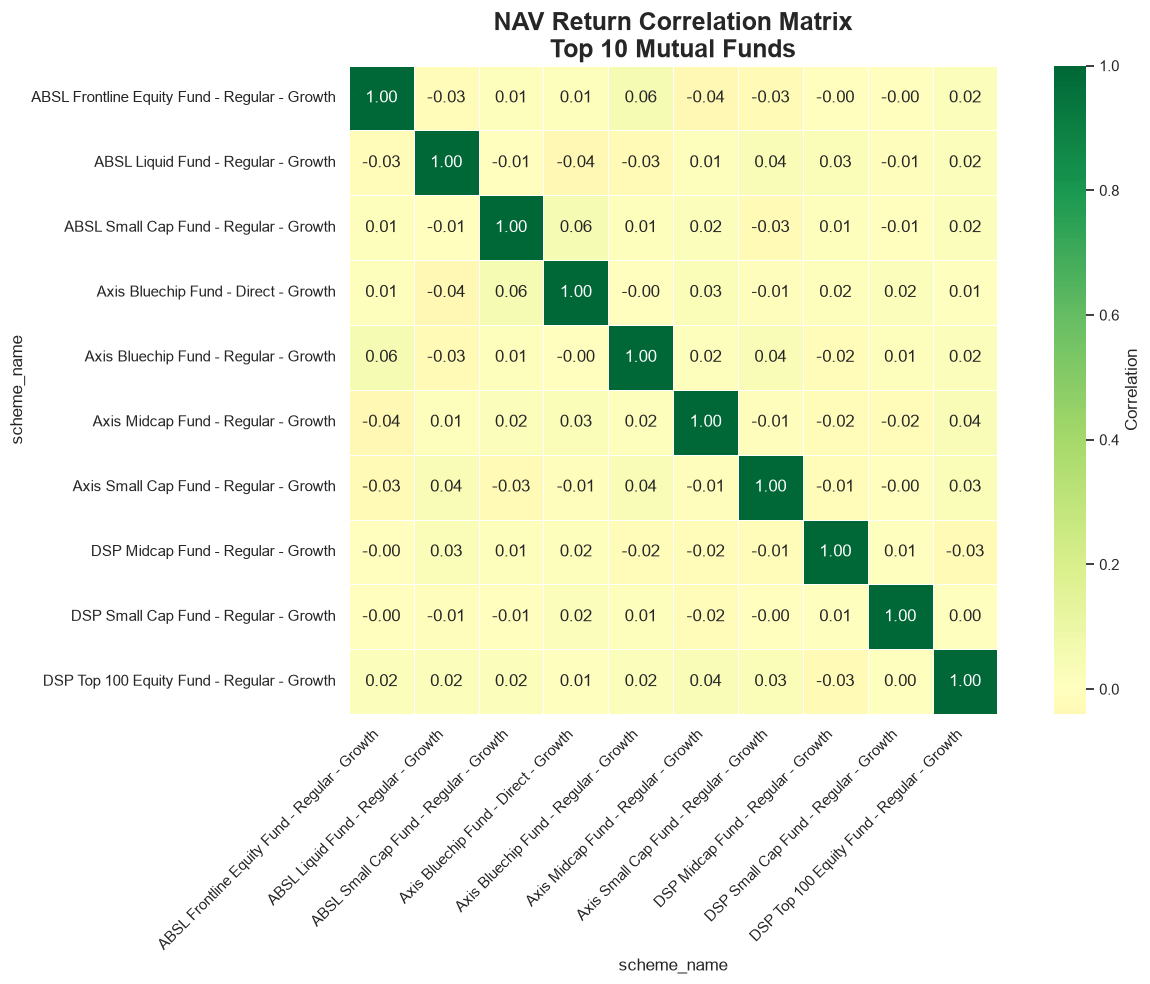

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(

    corr_matrix,

    annot=True,

    cmap="RdYlGn",

    center=0,

    fmt=".2f",

    linewidths=0.5,

    square=True,

    cbar_kws={

        "label":"Correlation"

    }

)

plt.title(

    "NAV Return Correlation Matrix\nTop 10 Mutual Funds",

    fontsize=18,

    weight="bold"

)

plt.xticks(

    rotation=45,

    ha="right"

)

plt.yticks(

    rotation=0

)

plt.tight_layout()

plt.show()

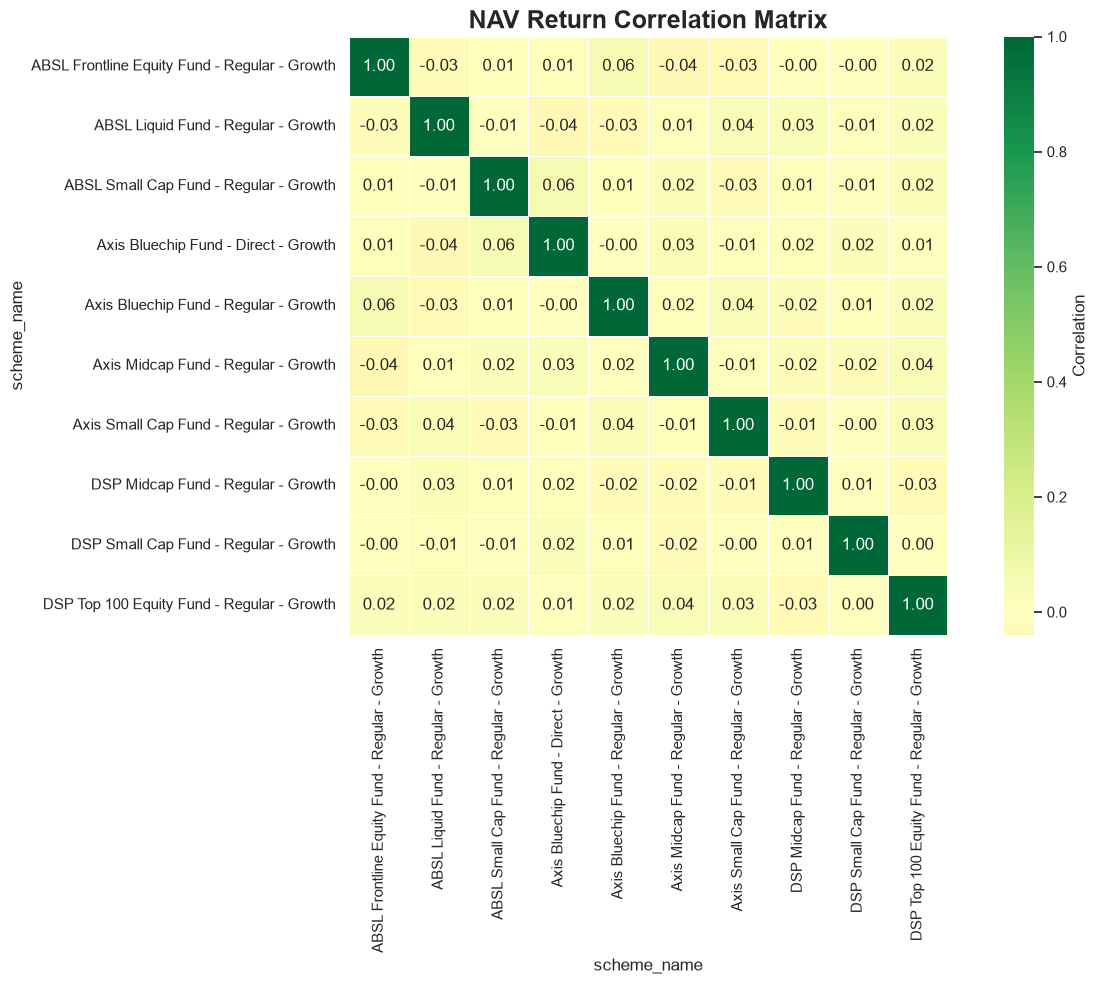

✅ Heatmap Saved Successfully


In [11]:
os.makedirs("dashboard", exist_ok=True)

plt.figure(figsize=(14,10))

sns.heatmap(

    corr_matrix,

    annot=True,

    cmap="RdYlGn",

    center=0,

    fmt=".2f",

    linewidths=0.5,

    square=True,

    cbar_kws={

        "label":"Correlation"

    }

)

plt.title(

    "NAV Return Correlation Matrix",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    "dashboard/nav_return_correlation_heatmap.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ Heatmap Saved Successfully")